# Lab: Relationships in Space and Time

Florida red tide is caused primarily by high concentrations of the microscopic alga *Karenia brevis*. The organism can produce toxins that harm marine life and cause respiratory irritation near affected shorelines. A bloom does not remain in one fixed place: winds and currents can move and disperse it while its concentration changes.

This lab examines part of the unusually long 2017–2019 Florida red-tide bloom. From June through November 2018, documented bloom concentrations expanded beyond southwest Florida and were detected in the Panhandle and, for part of the period, along the Atlantic coast.

## Learning goals

By the end of this lab, you should be able to:

- prepare and check a temporal feature;
- summarize observations by month;
- create and interpret an interactive time-series plot;
- map observations using exact latitude and longitude coordinates;
- animate spatial observations through time with Plotly Express; and
- distinguish documented sample locations from the complete extent of an environmental event.

## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response. Do not submit an AI response that you cannot explain.

## Dataset

The course dataset was prepared from the Florida Fish and Wildlife Conservation Commission's [Historic Harmful Algal Bloom Events 2015–2023 GIS layer](https://gis.myfwc.com/mapping/rest/services/Open_Data/Historic_Harmful_Algal_Bloom_Events_2015___2023/MapServer/12). It contains **7,292 water samples** collected from June 1 through November 30, 2018.

These are sampling records, not a continuous measurement of every part of Florida's coastal water. Sampling included routine monitoring, research, and additional event-response sampling when a bloom was suspected or already known.

# Step 1: Question

> **How did the location and concentration of documented Florida red tide change from June through November 2018?**

**During which month do you predict the greatest share of samples reached bloom concentration?**

Your answer: August

**Where around Florida do you predict bloom concentrations will appear by the end of this period?**

Your answer: Tarpon Bay

# Step 2: Data

## 1. Import the libraries

Import Pandas and Plotly Express using their conventional aliases.

In [1]:
# Write your code here.
import pandas as pd
import plotly.express as px

## 2. Read the data

Read `data/florida_red_tide_samples_june_november_2018.csv` into a DataFrame named `red_tide`. Use `parse_dates=["sample_date"]` so Pandas stores the sample date as a datetime rather than text.

In [2]:
# Write your code here.

red_tide = pd.read_csv("data/florida_red_tide_samples_june_november_2018.csv", parse_dates=["sample_date"])

## 3. Preview and inspect the DataFrame

Display the first five rows, last five rows, stored data types, and missing-value counts.

In [3]:
# Write your code here.
red_tide.head(5)

,sample_date,location,latitude,longitude,sample_depth_m,karenia_brevis_cells_per_liter,abundance_category
0,2018-06-01,Red Reef Park Beach,26.36043,-80.06847,0.5,0.0,Not present/background
1,2018-06-01,Gumbo Limbo Nature Center (Lake Wyman),26.36751,-80.07118,0.5,0.0,Not present/background
2,2018-06-01,Bay Dock (Sarasota Bay),27.33160,-82.57790,0.5,5000.0,Very low
3,2018-06-01,New Pass Dock (Sarasota Bay),27.33375,-82.57938,0.5,1000.0,Not present/background
4,2018-06-01,Dixie Highway Bridge; E of (Indian River),27.85566,-80.49085,1.3,0.0,Not present/background


In [4]:
red_tide.tail(5)

,sample_date,location,latitude,longitude,sample_depth_m,karenia_brevis_cells_per_liter,abundance_category
7287,2018-11-29,Brooks Bridge; W of (Santa Rosa Sound),30.400800,-86.600800,0.1,0.0,Not present/background
7288,2018-11-30,Gasparilla Island; 10 mi W of,26.722583,-82.366933,0.5,20667.0,Low
7289,2018-11-30,Gasparilla Island; 13 mi W of,26.760700,-82.475550,0.5,391020.0,Medium
7290,2018-11-30,Bay Dock (Sarasota Bay),27.331600,-82.577900,0.5,534000.0,Medium
7291,2018-11-30,New Pass Dock (Sarasota Bay),27.333750,-82.579380,0.5,274000.0,Medium


In [5]:
red_tide.info()

<class 'pandas.DataFrame'>
RangeIndex: 7292 entries, 0 to 7291
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   sample_date                     7292 non-null   datetime64[us]
 1   location                        7292 non-null   str           
 2   latitude                        7292 non-null   float64       
 3   longitude                       7292 non-null   float64       
 4   sample_depth_m                  7259 non-null   float64       
 5   karenia_brevis_cells_per_liter  7292 non-null   float64       
 6   abundance_category              7292 non-null   str           
dtypes: datetime64[us](1), float64(4), str(2)
memory usage: 714.8 KB


In [6]:
red_tide.isnull().sum()

sample_date                        0
location                           0
latitude                           0
longitude                          0
sample_depth_m                    33
karenia_brevis_cells_per_liter     0
abundance_category                 0
dtype: int64

### Data dictionary

| Feature | Meaning |
| --- | --- |
| `sample_date` | Calendar date on which the water sample was collected |
| `location` | Description or name of the sampling location |
| `latitude` | Sample latitude in decimal degrees north |
| `longitude` | Sample longitude in decimal degrees; values west of the prime meridian are negative |
| `sample_depth_m` | Sampling depth in meters |
| `karenia_brevis_cells_per_liter` | Number of *Karenia brevis* cells measured per liter of water |
| `abundance_category` | FWC concentration category calculated from the cell count |

The FWC categories are:

- **Not present/background:** 0–1,000 cells per liter
- **Very low:** over 1,000–10,000
- **Low:** over 10,000–100,000
- **Medium:** over 100,000–1,000,000
- **High:** over 1,000,000

For this lab, a sample is at **bloom concentration** when it contains at least 100,000 cells per liter.

Complete the table using the data dictionary, `.info()`, and `.isnull().sum()`.

| Feature | Feature type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `sample_date` | temporal | datetime64[us] | 0 |
| `location` | categorical | str | 0 |
| `latitude` | quantitative | float64 | 0 |
| `longitude` | quantitative | float64 | 0 |
| `sample_depth_m` | quantitative | float64 | 33 |
| `karenia_brevis_cells_per_liter` | quantitative | float64 | 0 |
| `abundance_category` | categorical | str | 0 |

**What does one row represent?**

Your answer: Each row represents one red tide sample, including the sample date, location and geographic coordinates, sampling depth, the measured abundance of Karenia brevis cells per liter, and its corresponding abundance category.


**Why can the same location appear in more than one row?**

Your answer: The same location can appear in more than one row because multiple samples may be collected from the same location on different dates or at different depths.

# Step 3: Operation

## 4. Sort the samples by date

Sort `red_tide` by `sample_date`. Use `inplace=True` to modify the existing DataFrame rather than creating another one.

In [7]:
# Write your code here.
red_tide.sort_values("sample_date", inplace=True)

## 5. Create monthly time features

Create `month` by using datetime methods to convert each `sample_date` to a monthly period and then back to a timestamp. The resulting timestamp represents the first day of its month and can be sorted chronologically.

Then create `month_label` with `.dt.strftime("%B %Y")`. This creates readable labels such as `June 2018` for the animation.

In [8]:
# Write your code here.
red_tide["month"] = red_tide["sample_date"].dt.to_period("M").dt.to_timestamp()
red_tide["month_label"] = red_tide["month"].dt.strftime("%B %Y")

## 6. Identify samples at bloom concentration

Create a Boolean feature named `bloom_level` that is `True` when `karenia_brevis_cells_per_liter` is at least 100,000 and `False` otherwise.

In [9]:
# Write your code here.

red_tide["bloom_level"] = red_tide["karenia_brevis_cells_per_liter"] >= 100000

## 7. Create a monthly summary

Group the records by `month` and use `.agg()` to calculate:

- `total_samples`: the number of cell-count records in each month; and
- `bloom_samples`: the sum of `bloom_level` in each month.

Summing works because Pandas evaluates `True` as 1 and `False` as 0. Use `.reset_index()` to return `month` to a regular column.

Then calculate `percent_bloom` as the number of bloom samples divided by the total number of samples, multiplied by 100. Display `monthly_summary`.

In [10]:
# Write your code here.

monthly_summary = (red_tide.groupby("month").agg(total_samples =("karenia_brevis_cells_per_liter", "count"), bloom_samples=("bloom_level", "sum"))
.reset_index())

monthly_summary["percent_bloom"] = (monthly_summary["bloom_samples"] / monthly_summary["total_samples"] * 100)

monthly_summary

,month,total_samples,bloom_samples,percent_bloom
0,2018-06-01,991,119,12.008073
1,2018-07-01,865,126,14.566474
2,2018-08-01,1236,364,29.449838
3,2018-09-01,1196,238,19.899666
4,2018-10-01,1855,290,15.633423
5,2018-11-01,1149,289,25.152306


## 8. Prepare the map data

To keep the spatial figures readable, create `map_data` containing samples with more than 10,000 cells per liter. Use `.copy()` because `map_data` will be a separate DataFrame used for the figures.

Create `month_order` from the unique `month_label` values. Because the rows were sorted first, the labels will be in chronological order. Also create `abundance_order` containing `Low`, `Medium`, and `High` in that order.

Samples at or below 10,000 cells per liter remain in `red_tide` and in the monthly summary; they are omitted only from the maps.

In [11]:
# Write your code here.

map_data = red_tide[red_tide["karenia_brevis_cells_per_liter"] > 10000].copy()

month_order = red_tide["month_label"].unique()

abundance_order = ["Low", "Medium", "High"]

# Step 4: Check

## 9. Check the prepared data

Display:

- the number of rows;
- the earliest and latest dates;
- the number of unique months;
- missing-value counts for the date, coordinates, cell count, and depth; and
- descriptive statistics for latitude, longitude, depth, and cell count.

In [12]:
# Write your code here.

print("Rows:", len(map_data))
print("Earliest date:", map_data["sample_date"].min())
print("Latest date:", map_data["sample_date"].max())
print("Unique months:", map_data["month"].nunique())

print(map_data[
        [
            "sample_date",
            "latitude",
            "longitude",
            "karenia_brevis_cells_per_liter",
            "sample_depth_m"
        ]
    ].isnull().sum())

Rows: 2131
Earliest date: 2018-06-04 00:00:00
Latest date: 2018-11-30 00:00:00
Unique months: 6
sample_date                       0
latitude                          0
longitude                         0
karenia_brevis_cells_per_liter    0
sample_depth_m                    8
dtype: int64


In [13]:
print(map_data[
        [
            "sample_date",
            "latitude",
            "longitude",
            "sample_depth_m",
            "karenia_brevis_cells_per_liter"
        ]
    ].describe())

                      sample_date     latitude    longitude  sample_depth_m  \
count                        2131  2131.000000  2131.000000     2123.000000   
mean   2018-09-12 11:25:11.966213    27.192202   -82.393608        1.063542   
min           2018-06-04 00:00:00    24.483000   -87.293000        0.100000   
25%           2018-08-08 00:00:00    26.679800   -82.580240        0.500000   
50%           2018-09-14 00:00:00    27.100340   -82.448000        0.500000   
75%           2018-10-24 00:00:00    27.373170   -82.191730        0.500000   
max           2018-11-30 00:00:00    30.427583   -79.959217       25.000000   
std                           NaN     0.866931     1.125372        2.532663   

       karenia_brevis_cells_per_liter  
count                    2.131000e+03  
mean                     1.871339e+06  
min                      1.033300e+04  
25%                      6.133300e+04  
50%                      2.537640e+05  
75%                      1.094561e+06  
max     

**Why do the 33 missing depth values not require us to remove those records from this analysis?**

Your answer: The analysis does not require sample_depth_m depth to analyze how the location and concentration of documented Florida red tide changed from June through November 2018. The records still contain the date, geographic coordinates, and cell-count information needed for the research question.

## 10. Check the aggregation

Display `monthly_summary`, then compare the sum of `total_samples` with the number of rows in `red_tide`. Compare the sum of `bloom_samples` with the sum of `bloom_level` in the original DataFrame.

In [14]:
# Write your code here.

display(monthly_summary)

print("Total samples in monthly summary:", monthly_summary['total_samples'].sum())

print("Rows in red tide:", len(red_tide))

print("Bloom samples in monthly summary:", monthly_summary['bloom_samples'].sum())

print("Bloom samples in red tide:", red_tide['bloom_level'].sum())



,month,total_samples,bloom_samples,percent_bloom
0,2018-06-01,991,119,12.008073
1,2018-07-01,865,126,14.566474
2,2018-08-01,1236,364,29.449838
3,2018-09-01,1196,238,19.899666
4,2018-10-01,1855,290,15.633423
5,2018-11-01,1149,289,25.152306


Total samples in monthly summary: 7292
Rows in red tide: 7292
Bloom samples in monthly summary: 1426
Bloom samples in red tide: 1426


**What kind of preparation error could be revealed if either pair of totals did not match?**

Your answer: If either pair of totals did not match, it could indicate that records were accidentally removed or filtered during data preparation. For example, samples with missing sample_depth_m may have been removed even though they should have remained in red_tide for this analysis. It could also indicate that the monthly summary was created from a filtered DataFrame like map_data instead of the original red_tide DataFrame.

# Step 5: Evidence

## 11. Plot the monthly percentage at bloom concentration

Use `px.line()` with `monthly_summary` to plot `month` against `percent_bloom`. Show markers and add a question-focused title and readable axis labels.

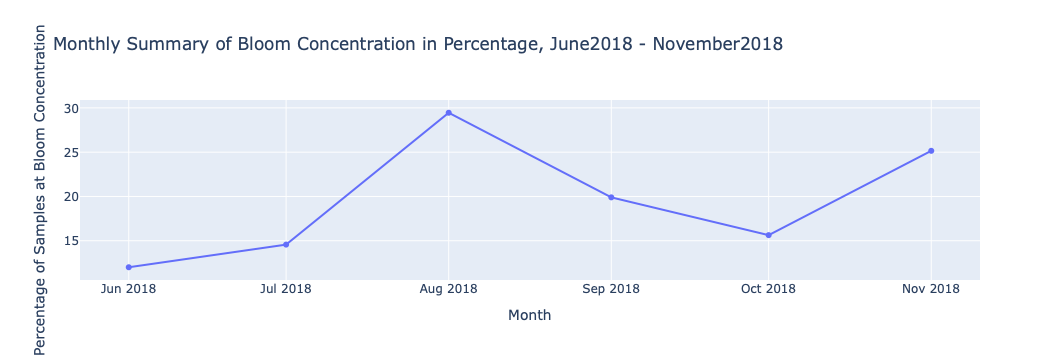

In [15]:
# Write your code here.
monthly_summary_figure = px.line(
    monthly_summary,
    x="month",
    y="percent_bloom",
    markers=True,
    title="Monthly Summary of Bloom Concentration in Percentage, June2018 - November2018",
    labels={
        "month": "Month",
        "percent_bloom": (
            "Percentage of Samples at Bloom Concentration"
        )
    }
)

monthly_summary_figure.show()


**During which month was the percentage of samples at bloom concentration highest?**

Your answer: August

**What temporal pattern do you observe from June through November?**

Your answer: From June through August, the percentage of samples at bloom concentration increased and reached its peak in August. It then decreased through October before increasing again in November.

## 12. Map the documented sample locations

Create a static `px.scatter_map()` using `map_data`.

- Use the exact `latitude` and `longitude` features.
- Map `abundance_category` to color.
- Use `location` as the hover name.
- Include `sample_date` and the cell count in `hover_data`.
- Use `abundance_order` in `category_orders`.
- Choose three ordered colors for Low, Medium, and High abundance.
- Use `zoom=4.5`, center the map at latitude 27.7 and longitude -82.3, use the `open-street-map` style, and set `height=650`.

The `abundance_category` values were already defined in the course dataset from the FWC cell-count ranges introduced in the data dictionary:

- **Low:** over 10,000–100,000 cells per liter
- **Medium:** over 100,000–1,000,000 cells per liter
- **High:** over 1,000,000 cells per liter

Because `map_data` contains only samples above 10,000 cells per liter, these are the three categories that appear in the map legend. You do not need to calculate the categories again.



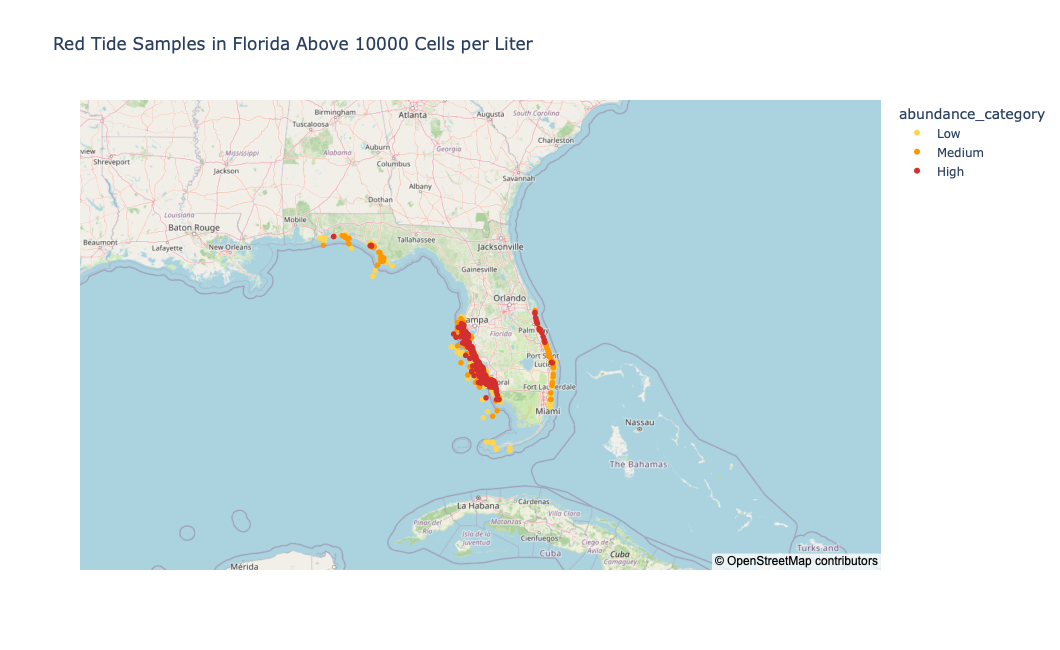

In [16]:
# Write your code here.

map_figure = px.scatter_map(
    map_data,
    lat="latitude",
    lon="longitude",
    color="abundance_category",
    hover_name="location",
    hover_data={
        "sample_date": True,
        "karenia_brevis_cells_per_liter": True,
        "latitude": ":.1f",
        "longitude": ":.1f"
    },
    category_orders={"abundance_category":abundance_order},
    color_discrete_sequence=["#FFD54F", "#FF9800", "#D32F2F"],
    size_max=24,
    zoom=4.5,
    center={"lat": 27.7, "lon": -82.3},
    map_style="open-street-map",
    title="Red Tide Samples in Florida Above 10000 Cells per Liter",
    height=650
)

map_figure.show()

**What spatial pattern is visible in the static map?**

Your answer: The map shows that high abundant samples are concentrated mostly along the southwestern coast of Florida. Some high abundant samples also appear in the southeastern part of the state while few high abundant samples are visible in the northwestern part of Florida.

**What important temporal information is difficult to recover from the static map?**

Your answer: It is difficult to determine which months the samples with higher abundance occurred because the static map does not clearly show how the sample locations and abundance changed over time.

## 13. Animate the documented sample locations

Re-create the spatial figure with `animation_frame="month_label"`. Add the chronological `month_order` to `category_orders` so the slider follows June through November.

Keep the map center, zoom, height, category order, and colors fixed. This makes changes among frames easier to interpret as changes in the observations rather than changes in the display.

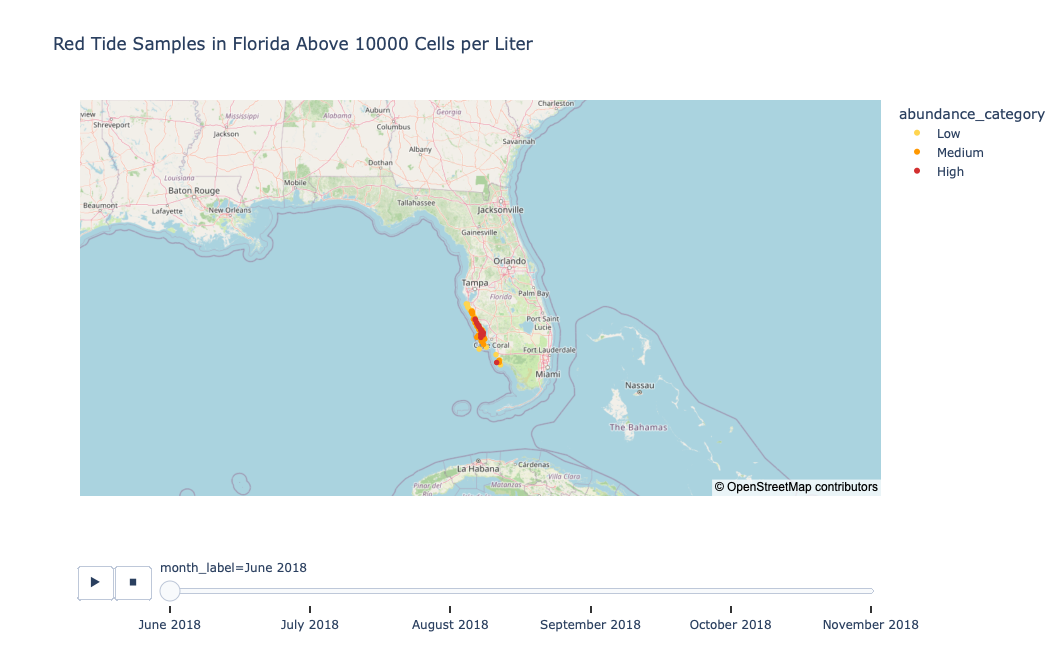

In [17]:
# Write your code here.

map_animation = px.scatter_map(
    map_data,
    lat="latitude",
    lon="longitude",
    color="abundance_category",
    animation_frame="month_label",
    hover_name="location",
    hover_data={
        "sample_date": True,
        "karenia_brevis_cells_per_liter": True,
        "latitude": ":.1f",
        "longitude": ":.1f"
    },
    category_orders={"month_label":month_order, "abundance_category": abundance_order},
    color_discrete_sequence=["#FFD54F", "#FF9800", "#D32F2F"],
    size_max=24,
    zoom=4.5,
    center={"lat": 27.7, "lon": -82.3},
    map_style="open-street-map",
    title="Red Tide Samples in Florida Above 10000 Cells per Liter",
    height=650
)

map_animation.show()

**How did the documented bloom's geographic pattern change from June through November?**

Your answer: The documented blooms were initially concentrated along the southwestern coast of Florida in June. By September, some blooms appeared in the southeastern and northwestern parts of the state. The number of documented blooms in the southeastern region increased substantially in October before decreasing in November while the northwestern region increased slightly in October and remained relatively consistent afterward. Meanwhile, the southwestern region increased substantially through August, remained relatively consistent in September, decreased slightly in October, and increased again in November.



**Which figure makes the timing of geographic expansion easiest to see?**

Your answer: The animation figure makes the timing of geographic expansion easiest to see because it shows the documented samples changing location and abundance from month to month. This makes it easier to see when blooms appeared or increased in different regions of Florida.

# Step 6: Conclusion and limitation

**Write a concise conclusion that answers the research question using evidence from both the time-series plot and the animated map.**

Your answer: From June through November 2018, the time-series plot showed that the percentage of bloom concentration samples increased to a peak in August, decreased through October, and increased again in November. The animated map showed that blooms were most consistently concentrated in southwestern Florida while additional blooms appeared in the southeastern and northwestern regions later in the period. The figures show that both the concentration and geographic distribution of documented red tide changed over time, with the southwestern region showing the most noticeable changes.


**Why does the animation show documented sample locations rather than the complete geographic boundary of the bloom?**

Your answer: The animation shows documented sample locations because the dataset contains observations collected at specific sampling locations and not continuous measurements across the entire area.

**Why should the monthly percentages not be interpreted as the percentage of all Florida coastal water affected by red tide?**

Your answer: The monthly percentages should not be interpreted as the percentage of all Florida coastal water affected by red tide because they are based only on the documented samples collected and not on measurements covering the entire Florida coastline.

## AI-use reflection

**State whether you used an AI tool and, if you did, identify one suggestion you checked and explain what you accepted, modified, or rejected.**

Your answer: I used ChatGPT to help me understand why my monthly summary was not being created when I received the error: "Label(s) ['bloom_level'] do not exist". I realized that when I created the Boolean feature, I had not added it as a column to the red_tide DataFrame. I changed bloom_level = red_tide["karenia_brevis_cells_per_liter"] >= 100000 to red_tide["bloom_level"] = red_tide["karenia_brevis_cells_per_liter"] >= 100000 so that the feature was stored in red_tide. I accepted this suggestion because it fixed the error and allowed the monthly summary to use the bloom_level column.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested DataFrame and feature names.
- Complete every written-response cell.
- Give every figure a readable title and axis labels when axes are present.
- Support the conclusion with evidence from the figures and calculated values.
- Distinguish sample locations from the complete extent of the bloom.
- Keep the notebook organized and readable.
- Submit the completed notebook by the deadline.